In [4]:
# Libraries
import sys
sys.path.append('../')

import numpy as np
import matplotlib.pyplot as plt
import json
import torch
from torch import nn
from data_processors import *
from scipy.stats import sem, t
import os
from tqdm import tqdm
from policies import DeepGaussianPolicy
from envs import ContCartPoleFriction
import copy
import math
import imageio


c:\Users\Sara\Miniconda3\envs\learnRlEnv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Funzione per caricare i dati da un percorso
def load_trials(base_path, n_exp):
    trial_performances = []
    for i in range(n_exp):
        trial_path = os.path.join(base_path, f"trial_{i}")
        if os.path.isdir(trial_path):
            try:
                file_path = os.path.join(trial_path, "results.json")
                with open(file_path, 'r') as file:
                    data = json.load(file)
                    trial_performances.append(data["performance"])
            except (FileNotFoundError, json.JSONDecodeError) as e:
                print(f"Errore nel leggere {file_path}: {e}")
    return np.array(trial_performances)  # Converte in array per calcoli successivi

In [20]:
paths = [
   r"C:\Users\Sara\Desktop\learnRL\results_bpo\test_05_28-12_53_PG_300_cartpole_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00",
   r"C:\Users\Sara\Desktop\learnRL\results_bpo\test-friction-0.1_05_28-17_59_PG_150_cartpole_friction_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00",
   r"C:\Users\Sara\Desktop\learnRL\results_bpo\test-friction-0.2_05_28-19_07_PG_150_cartpole_friction_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00",
   r"C:\Users\Sara\Desktop\learnRL\results_bpo\test-friction-0.3_05_29-00_37_PG_150_cartpole_friction_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00",
   r"C:\Users\Sara\Desktop\learnRL\results_bpo\test-friction-0.4_05_29-01_33_PG_150_cartpole_friction_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00",
   r"C:\Users\Sara\Desktop\learnRL\results_bpo\test-friction-0.5_05_29-02_36_PG_150_cartpole_friction_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00"

]

In [21]:
# Lista per memorizzare le performance per ogni set
all_performances = []

for path in paths:
    performances = load_trials(path, n_exp=10)
    if performances.size > 0:
        all_performances.append(performances)

<Figure size 640x480 with 0 Axes>

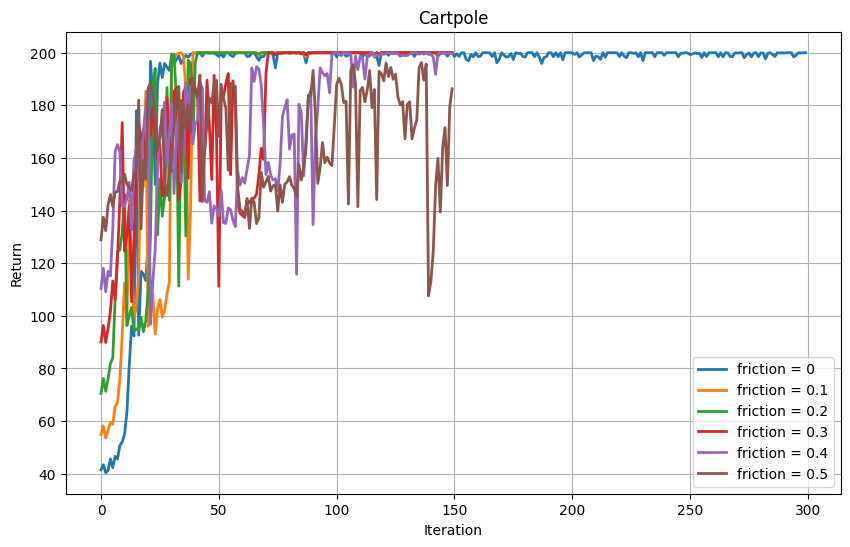

In [22]:
lab = ["friction = 0", "friction = 0.1", "friction = 0.2", "friction = 0.3", "friction = 0.4", "friction = 0.5"]
# Plot dei grafici
plt.clf()
# plt.figure(figsize=(6.5, 4.5))
plt.figure(figsize=(10, 6))

for i, performances in enumerate(all_performances):
    if performances.size > 0:
         # Calcola la media e gli intervalli di confidenza
        mean_performance = np.mean(performances, axis=0)
        std_performance = np.std(performances, axis=0)

        # Plot della curva media
        plt.plot(mean_performance, linewidth=2, label=lab[i])

        # Plot dell'intervallo di confidenza
        lower = mean_performance-(std_performance)*1.96/np.sqrt(performances.shape[0])
        higher = mean_performance+(std_performance)*1.96/np.sqrt(performances.shape[0])

        plt.fill_between(
            range(len(mean_performance)),
            lower,
            higher,
            alpha=0.2
        )

        # print(np.mean(mean_performance))
        # print(np.mean(lower))
        # print(np.mean(higher))

# Etichette e titolo
plt.title("Cartpole")
plt.xlabel("Iteration")
plt.ylabel("Return")

plt.legend()
plt.grid()
# plt.ylim(bottom=-80)
# plt.xlim(right=80)
# Salva e mostra il grafico
# plt.savefig("dam_1825_b10_g999.pdf", format='pdf')
plt.show()

  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [00:11<00:00, 17.20it/s]


Mean reward: 200.0 Std reward: 0.0
Mean cost: -2.353519204188432 Std cost: 1.141662329126514


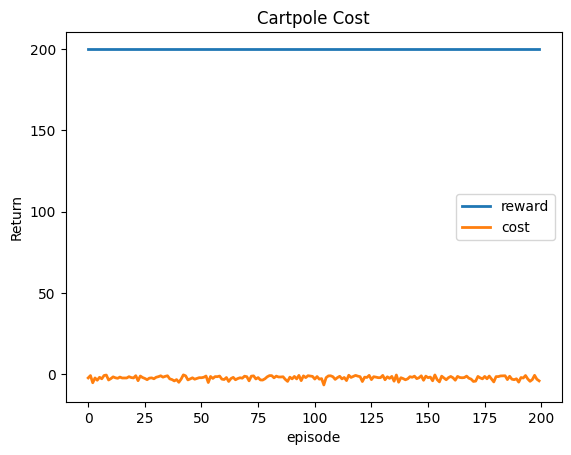

In [9]:
HORIZON = 200
GAMMA = 1
MU_P = 0
STD_DEV = 1

NUM_EPISODES = 200

env =  ContCartPoleFriction(horizon=HORIZON, gamma=GAMMA, mu_p = MU_P, render_mode="rgb_array")
s_dim = env.state_dim
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, 50, bias=False),
            nn.Tanh(),
            nn.Linear(50, 25, bias=False),
            nn.Tanh(),
            nn.Linear(25, a_dim, bias=False),
            nn.Tanh()
        )
model_desc = dict(
            layers_shape=[(s_dim, 50), (50, 25), (25, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters=np.load(r"C:\Users\Sara\Desktop\learnRL\results_bpo\test_05_28-12_53_PG_300_cartpole_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00\trial_0\policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )


all_episode_rewards = []
all_episode_costs = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    episode_costs = []
    done = False
    env.reset()
    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        if rew == 0 :
            cost = -1
        else:
            cost = - abs (math.sin(obs[2]))
        episode_rewards.append(rew * GAMMA ** t)
        episode_costs.append(cost * GAMMA ** t)
        if done:
            episode_costs.extend([-1] * (HORIZON - t - 1))
            break
    all_episode_rewards.append(sum(episode_rewards))
    all_episode_costs.append(sum(episode_costs))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)


plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Cartpole Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()

mean_episode_cost = np.mean(all_episode_costs)
std_episode_cost = np.std(all_episode_costs)
print("Mean cost:", mean_episode_cost,
        "Std cost:", std_episode_cost)


plt.plot(all_episode_costs, linewidth=2, label="cost")
plt.title("Cartpole Cost")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
plt.legend()
plt.show
plt.savefig(r"C:\Users\sara\Desktop\presentation\plots\friction_0-0")

frames = []
env.reset()
for t in range(HORIZON): # iterate over the steps until termination
    obs = env.state
    action = pol.draw_action(obs)
    obs, rew, done, _ = env.step(action)
    frames.append( env.render())
    if done:
        break

imageio.mimsave(r"C:\Users\sara\Desktop\presentation\gifs\friction_0-0.gif", frames, duration=33)

### Average reward with optimal policy for friction = 0, when friction is 0.1 on cartpole

100%|██████████| 200/200 [00:06<00:00, 30.70it/s]


Mean reward: 200.0 Std reward: 0.0
Mean cost: -3.097254513926391 Std cost: 1.7310741248767965


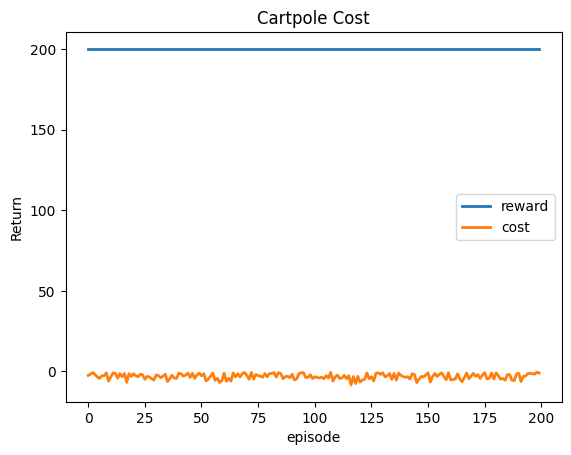

In [8]:
HORIZON = 200
GAMMA = 1
MU_P = 0.1
STD_DEV = 1

NUM_EPISODES = 200

env =  ContCartPoleFriction(horizon=HORIZON, gamma=GAMMA, mu_p = MU_P, render_mode="rgb_array")
s_dim = env.state_dim
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, 50, bias=False),
            nn.Tanh(),
            nn.Linear(50, 25, bias=False),
            nn.Tanh(),
            nn.Linear(25, a_dim, bias=False),
            nn.Tanh()
        )
model_desc = dict(
            layers_shape=[(s_dim, 50), (50, 25), (25, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters=np.load(r"C:\Users\Sara\Desktop\learnRL\results_bpo\test_05_28-12_53_PG_300_cartpole_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00\trial_0\policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )


all_episode_rewards = []
all_episode_costs = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    episode_costs = []
    done = False
    env.reset()
    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        if rew == 0 :
            cost = -1
        else:
            cost = - abs (math.sin(obs[2]))
        episode_rewards.append(rew * GAMMA ** t)
        episode_costs.append(cost * GAMMA ** t)
        if done:
            episode_costs.extend([-1] * (HORIZON - t - 1))
            break
    all_episode_rewards.append(sum(episode_rewards))
    all_episode_costs.append(sum(episode_costs))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)


plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Cartpole Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()

mean_episode_cost = np.mean(all_episode_costs)
std_episode_cost = np.std(all_episode_costs)
print("Mean cost:", mean_episode_cost,
        "Std cost:", std_episode_cost)


plt.plot(all_episode_costs, linewidth=2, label="cost")
plt.title("Cartpole Cost")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
plt.legend()
plt.show
plt.savefig(r"C:\Users\sara\Desktop\presentation\gifs\friction_0-01")

frames = []
env.reset()
for t in range(HORIZON): # iterate over the steps until termination
    obs = env.state
    action = pol.draw_action(obs)
    obs, rew, done, _ = env.step(action)
    frames.append( env.render())
    if done:
        break

imageio.mimsave(r"C:\Users\sara\Desktop\presentation\gifs\friction_0-0.1.gif", frames, duration=33)

### Average reward with optimal policy for friction = 0, when friction is 0.2 on cartpole

  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [00:11<00:00, 16.77it/s]


Mean reward: 199.95 Std reward: 0.49749371855331
Mean cost: -4.308825863332577 Std cost: 2.814202445230143


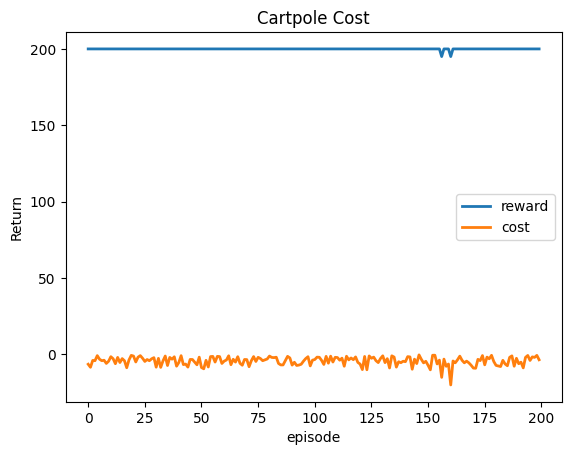

In [10]:
HORIZON = 200
GAMMA = 1
MU_P = 0.2
STD_DEV = 1

NUM_EPISODES = 200

env =  ContCartPoleFriction(horizon=HORIZON, gamma=GAMMA, mu_p = MU_P, render_mode="rgb_array")
s_dim = env.state_dim
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, 50, bias=False),
            nn.Tanh(),
            nn.Linear(50, 25, bias=False),
            nn.Tanh(),
            nn.Linear(25, a_dim, bias=False),
            nn.Tanh()
        )
model_desc = dict(
            layers_shape=[(s_dim, 50), (50, 25), (25, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters=np.load(r"C:\Users\Sara\Desktop\learnRL\results_bpo\test_05_28-12_53_PG_300_cartpole_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00\trial_0\policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )


all_episode_rewards = []
all_episode_costs = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    episode_costs = []
    done = False
    env.reset()
    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        if rew == 0 :
            cost = -1
        else:
            cost = - abs (math.sin(obs[2]))
        episode_rewards.append(rew * GAMMA ** t)
        episode_costs.append(cost * GAMMA ** t)
        if done:
            episode_costs.extend([-1] * (HORIZON - t - 1))
            break
    all_episode_rewards.append(sum(episode_rewards))
    all_episode_costs.append(sum(episode_costs))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)


plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Cartpole Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()

mean_episode_cost = np.mean(all_episode_costs)
std_episode_cost = np.std(all_episode_costs)
print("Mean cost:", mean_episode_cost,
        "Std cost:", std_episode_cost)


plt.plot(all_episode_costs, linewidth=2, label="cost")
plt.title("Cartpole Cost")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
plt.legend()
plt.show
plt.savefig(r"C:\Users\sara\Desktop\presentation\plots\friction_0-02")

frames = []
env.reset()
for t in range(HORIZON): # iterate over the steps until termination
    obs = env.state
    action = pol.draw_action(obs)
    obs, rew, done, _ = env.step(action)
    frames.append( env.render())
    if done:
        break

imageio.mimsave(r"C:\Users\sara\Desktop\presentation\gifs\friction_0-0.2.gif", frames, duration=33)


### Average reward with optimal policy for friction = 0, when friction is 0.3 on cartpole

100%|██████████| 200/200 [00:11<00:00, 17.41it/s]


Mean reward: 199.925 Std reward: 0.7611668673819163
Mean cost: -5.9080073726343105 Std cost: 3.2048191681695264


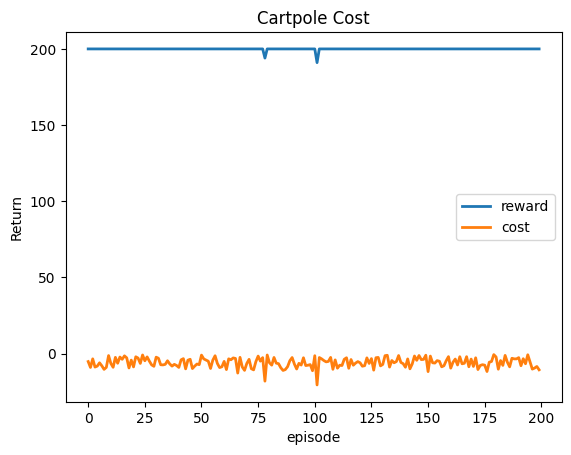

In [12]:
HORIZON = 200
GAMMA = 1
MU_P = 0.3
STD_DEV = 1

NUM_EPISODES = 200

env =  ContCartPoleFriction(horizon=HORIZON, gamma=GAMMA, mu_p = MU_P, render_mode = "rgb_array")
s_dim = env.state_dim
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, 50, bias=False),
            nn.Tanh(),
            nn.Linear(50, 25, bias=False),
            nn.Tanh(),
            nn.Linear(25, a_dim, bias=False),
            nn.Tanh()
        )
model_desc = dict(
            layers_shape=[(s_dim, 50), (50, 25), (25, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters=np.load(r"C:\Users\Sara\Desktop\learnRL\results_bpo\test_05_28-12_53_PG_300_cartpole_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00\trial_0\policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )


all_episode_rewards = []
all_episode_costs = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    episode_costs = []
    done = False
    env.reset()
    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        if rew == 0 :
            cost = -1
        else:
            cost = - abs (math.sin(obs[2]))
        episode_rewards.append(rew * GAMMA ** t)
        episode_costs.append(cost * GAMMA ** t)
        if done:
            episode_costs.extend([-1] * (HORIZON - t - 1))
            break
    all_episode_rewards.append(sum(episode_rewards))
    all_episode_costs.append(sum(episode_costs))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)


plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Cartpole Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()

mean_episode_cost = np.mean(all_episode_costs)
std_episode_cost = np.std(all_episode_costs)
print("Mean cost:", mean_episode_cost,
        "Std cost:", std_episode_cost)


plt.plot(all_episode_costs, linewidth=2, label="cost")
plt.title("Cartpole Cost")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
plt.legend()
plt.show
plt.savefig(r"C:\Users\sara\Desktop\presentation\plots\friction_0-03")

frames = []
env.reset()
for t in range(HORIZON): # iterate over the steps until termination
    obs = env.state
    action = pol.draw_action(obs)
    obs, rew, done, _ = env.step(action)
    frames.append( env.render())
    if done:
        break

imageio.mimsave(r"C:\Users\sara\Desktop\presentation\gifs\friction_0-0.3.gif", frames, duration=33)

### Average reward with optimal policy for friction = 0, when friction is 0.4 on cartpole

100%|██████████| 200/200 [00:06<00:00, 32.91it/s]


Mean reward: 199.725 Std reward: 1.43853223808158
Mean cost: -7.255474050363907 Std cost: 3.529472435953269


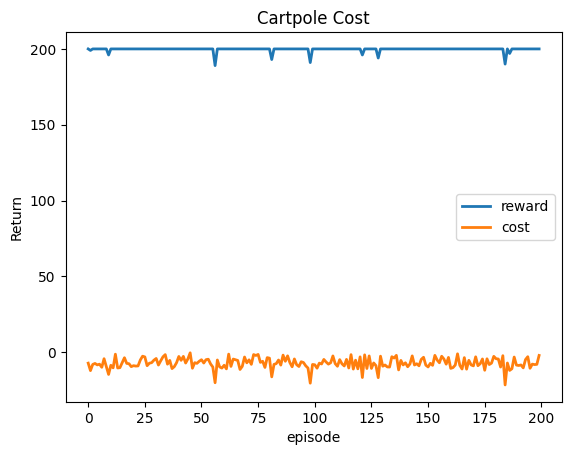

In [21]:
HORIZON = 200
GAMMA = 1
MU_P = 0.4
STD_DEV = 1

NUM_EPISODES = 200

env =  ContCartPoleFriction(horizon=HORIZON, gamma=GAMMA, mu_p = MU_P, render_mode="rgb_array")
s_dim = env.state_dim
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, 50, bias=False),
            nn.Tanh(),
            nn.Linear(50, 25, bias=False),
            nn.Tanh(),
            nn.Linear(25, a_dim, bias=False),
            nn.Tanh()
        )
model_desc = dict(
            layers_shape=[(s_dim, 50), (50, 25), (25, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters=np.load(r"C:\Users\Sara\Desktop\learnRL\results_bpo\test_05_28-12_53_PG_300_cartpole_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00\trial_0\policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )


all_episode_rewards = []
all_episode_costs = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    episode_costs = []
    done = False
    env.reset()
    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        if rew == 0 :
            cost = -1
        else:
            cost = - abs (math.sin(obs[2]))
        episode_rewards.append(rew * GAMMA ** t)
        episode_costs.append(cost * GAMMA ** t)
        if done:
            episode_costs.extend([-1] * (HORIZON - t - 1))
            break
    all_episode_rewards.append(sum(episode_rewards))
    all_episode_costs.append(sum(episode_costs))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)


plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Cartpole Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()

mean_episode_cost = np.mean(all_episode_costs)
std_episode_cost = np.std(all_episode_costs)
print("Mean cost:", mean_episode_cost,
        "Std cost:", std_episode_cost)


plt.plot(all_episode_costs, linewidth=2, label="cost")
plt.title("Cartpole Cost")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
plt.legend()
plt.show
plt.savefig(r"C:\Users\sara\Desktop\presentation\plots\friction_0-04")

frames = []
env.reset()
for t in range(HORIZON): # iterate over the steps until termination
    obs = env.state
    action = pol.draw_action(obs)
    obs, rew, done, _ = env.step(action)
    frames.append( env.render())
    if done:
        break

imageio.mimsave(r"C:\Users\sara\Desktop\presentation\gifs\friction_0-0.4.gif", frames, duration=33)

### Average reward with optimal policy for friction = 0, when friction is 0.5 on cartpole

100%|██████████| 200/200 [00:03<00:00, 61.43it/s]


Mean reward: 197.26 Std reward: 11.333684308290929
Mean cost: -9.27218339035966 Std cost: 11.935106798403526


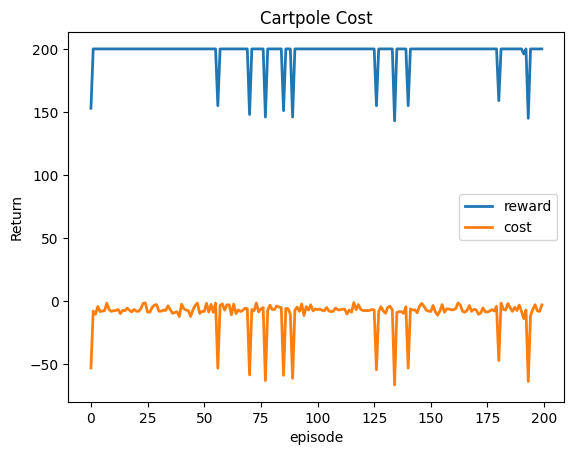

In [53]:
HORIZON = 200
GAMMA = 1
MU_P = 0.5
STD_DEV = 1

NUM_EPISODES = 200

env =  ContCartPoleFriction(horizon=HORIZON, gamma=GAMMA, mu_p = MU_P, render_mode="rgb_array")
s_dim = env.state_dim
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, 50, bias=False),
            nn.Tanh(),
            nn.Linear(50, 25, bias=False),
            nn.Tanh(),
            nn.Linear(25, a_dim, bias=False),
            nn.Tanh()
        )
model_desc = dict(
            layers_shape=[(s_dim, 50), (50, 25), (25, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters=np.load(r"C:\Users\Sara\Desktop\learnRL\results_bpo\test_05_28-12_53_PG_300_cartpole_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00\trial_0\policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )


all_episode_rewards = []
all_episode_costs = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    episode_costs = []
    done = False
    env.reset()
    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        if rew == 0 :
            cost = -1
        else:
            cost = - abs (math.sin(obs[2]))
        episode_rewards.append(rew * GAMMA ** t)
        episode_costs.append(cost * GAMMA ** t)
        if done:
            episode_costs.extend([-1] * (HORIZON - t - 1))
            break
    all_episode_rewards.append(sum(episode_rewards))
    all_episode_costs.append(sum(episode_costs))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)


plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Cartpole Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()

mean_episode_cost = np.mean(all_episode_costs)
std_episode_cost = np.std(all_episode_costs)
print("Mean cost:", mean_episode_cost,
        "Std cost:", std_episode_cost)


plt.plot(all_episode_costs, linewidth=2, label="cost")
plt.title("Cartpole Cost")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
plt.legend()
plt.show
plt.savefig(r"C:\Users\sara\Desktop\presentation\plots\friction_0-05")

frames = []
env.reset()
for t in range(HORIZON): # iterate over the steps until termination
    obs = env.state
    action = pol.draw_action(obs)
    obs, rew, done, _ = env.step(action)
    frames.append( env.render())
    if done:
        break

imageio.mimsave(r"C:\Users\sara\Desktop\presentation\gifs\friction_0-0.5.gif", frames, duration=33)

### Average reward with optimal policy for friction = 0.1, when friction is 0.1 on cartpole

100%|██████████| 200/200 [00:05<00:00, 34.11it/s]


Mean reward: 200.0 Std reward: 0.0
Mean cost: -3.1410207373005985 Std cost: 1.5017028781993669


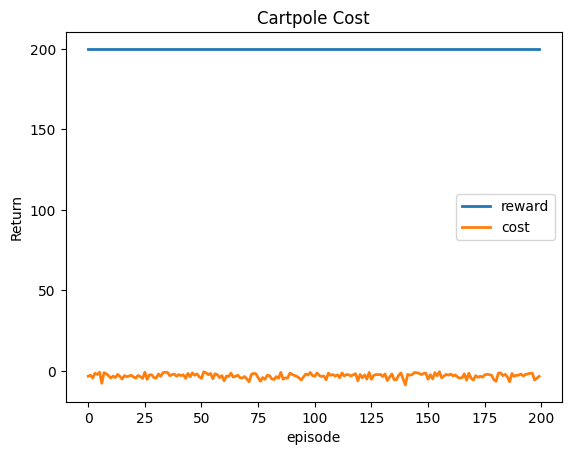

In [16]:
HORIZON = 200
GAMMA = 1
MU_P = 0.1
STD_DEV = 1

NUM_EPISODES = 200

env =  ContCartPoleFriction(horizon=HORIZON, gamma=GAMMA, mu_p = MU_P, render_mode="rgb_array")
s_dim = env.state_dim
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, 50, bias=False),
            nn.Tanh(),
            nn.Linear(50, 25, bias=False),
            nn.Tanh(),
            nn.Linear(25, a_dim, bias=False),
            nn.Tanh()
        )
model_desc = dict(
            layers_shape=[(s_dim, 50), (50, 25), (25, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters = np.load(r"C:\Users\Sara\Desktop\learnRL\results_bpo\test-friction-0.1_05_28-17_59_PG_150_cartpole_friction_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00\trial_0\policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )


all_episode_rewards = []
all_episode_costs = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    episode_costs = []
    done = False
    env.reset()
    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        if rew == 0 :
            cost = -1
        else:
            cost = - abs (math.sin(obs[2]))
        episode_rewards.append(rew * GAMMA ** t)
        episode_costs.append(cost * GAMMA ** t)
        if done:
            episode_costs.extend([-1] * (HORIZON - t - 1))
            break
    all_episode_rewards.append(sum(episode_rewards))
    all_episode_costs.append(sum(episode_costs))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)


plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Cartpole Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()

mean_episode_cost = np.mean(all_episode_costs)
std_episode_cost = np.std(all_episode_costs)
print("Mean cost:", mean_episode_cost,
        "Std cost:", std_episode_cost)


plt.plot(all_episode_costs, linewidth=2, label="cost")
plt.title("Cartpole Cost")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
plt.legend()
plt.show
plt.savefig(r"C:\Users\sara\Desktop\presentation\plots\friction_01-01")


frames = []
env.reset()
for t in range(HORIZON): # iterate over the steps until termination
    obs = env.state
    action = pol.draw_action(obs)
    obs, rew, done, _ = env.step(action)
    frames.append( env.render())
    if done:
        break

imageio.mimsave(r"C:\Users\sara\Desktop\presentation\gifs\friction_0.1-0.1.gif", frames, duration=33)

### Average reward with optimal policy for friction = 0.1, when friction is 0.2 on cartpole

100%|██████████| 200/200 [00:05<00:00, 37.49it/s]


Mean reward: 200.0 Std reward: 0.0
Mean cost: -4.004292013221255 Std cost: 2.1027840962068143


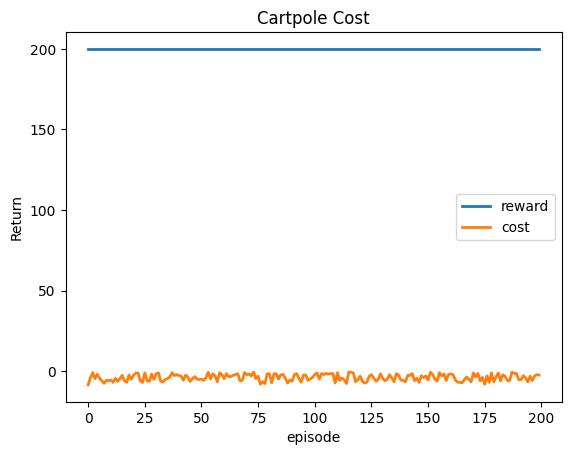

In [17]:
HORIZON = 200
GAMMA = 1
MU_P = 0.2
STD_DEV = 1

NUM_EPISODES = 200

env =  ContCartPoleFriction(horizon=HORIZON, gamma=GAMMA, mu_p = MU_P, render_mode="rgb_array")
s_dim = env.state_dim
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, 50, bias=False),
            nn.Tanh(),
            nn.Linear(50, 25, bias=False),
            nn.Tanh(),
            nn.Linear(25, a_dim, bias=False),
            nn.Tanh()
        )
model_desc = dict(
            layers_shape=[(s_dim, 50), (50, 25), (25, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters = np.load(r"C:\Users\Sara\Desktop\learnRL\results_bpo\test-friction-0.1_05_28-17_59_PG_150_cartpole_friction_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00\trial_0\policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )


all_episode_rewards = []
all_episode_costs = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    episode_costs = []
    done = False
    env.reset()
    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        if rew == 0 :
            cost = -1
        else:
            cost = - abs (math.sin(obs[2]))
        episode_rewards.append(rew * GAMMA ** t)
        episode_costs.append(cost * GAMMA ** t)
        if done:
            episode_costs.extend([-1] * (HORIZON - t - 1))
            break
    all_episode_rewards.append(sum(episode_rewards))
    all_episode_costs.append(sum(episode_costs))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)


plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Cartpole Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()

mean_episode_cost = np.mean(all_episode_costs)
std_episode_cost = np.std(all_episode_costs)
print("Mean cost:", mean_episode_cost,
        "Std cost:", std_episode_cost)


plt.plot(all_episode_costs, linewidth=2, label="cost")
plt.title("Cartpole Cost")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
plt.legend()
plt.show
plt.savefig(r"C:\Users\sara\Desktop\presentation\plots\friction_01-02")

frames = []
env.reset()
for t in range(HORIZON): # iterate over the steps until termination
    obs = env.state
    action = pol.draw_action(obs)
    obs, rew, done, _ = env.step(action)
    frames.append( env.render())
    if done:
        break

imageio.mimsave(r"C:\Users\sara\Desktop\presentation\gifs\friction_0.1-0.2.gif", frames, duration=33)

### Average reward with optimal policy for friction = 0.1, when friction is 0.3 on cartpole

100%|██████████| 200/200 [00:05<00:00, 34.34it/s]


Mean reward: 200.0 Std reward: 0.0
Mean cost: -4.9313648802866465 Std cost: 2.6212616190076368


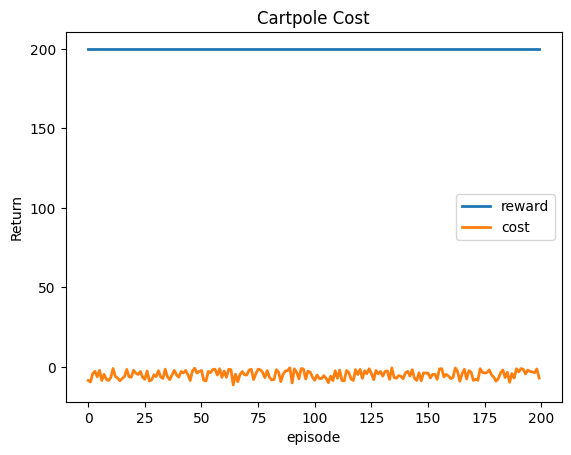

In [18]:
HORIZON = 200
GAMMA = 1
MU_P = 0.3
STD_DEV = 1

NUM_EPISODES = 200

env =  ContCartPoleFriction(horizon=HORIZON, gamma=GAMMA, mu_p = MU_P, render_mode="rgb_array")
s_dim = env.state_dim
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, 50, bias=False),
            nn.Tanh(),
            nn.Linear(50, 25, bias=False),
            nn.Tanh(),
            nn.Linear(25, a_dim, bias=False),
            nn.Tanh()
        )
model_desc = dict(
            layers_shape=[(s_dim, 50), (50, 25), (25, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters = np.load(r"C:\Users\Sara\Desktop\learnRL\results_bpo\test-friction-0.1_05_28-17_59_PG_150_cartpole_friction_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00\trial_0\policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )


all_episode_rewards = []
all_episode_costs = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    episode_costs = []
    done = False
    env.reset()
    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        if rew == 0 :
            cost = -1
        else:
            cost = - abs (math.sin(obs[2]))
        episode_rewards.append(rew * GAMMA ** t)
        episode_costs.append(cost * GAMMA ** t)
        if done:
            episode_costs.extend([-1] * (HORIZON - t - 1))
            break
    all_episode_rewards.append(sum(episode_rewards))
    all_episode_costs.append(sum(episode_costs))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)


plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Cartpole Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()

mean_episode_cost = np.mean(all_episode_costs)
std_episode_cost = np.std(all_episode_costs)
print("Mean cost:", mean_episode_cost,
        "Std cost:", std_episode_cost)


plt.plot(all_episode_costs, linewidth=2, label="cost")
plt.title("Cartpole Cost")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
plt.legend()
plt.show
plt.savefig(r"C:\Users\sara\Desktop\presentation\plots\friction_01-03")

frames = []
env.reset()
for t in range(HORIZON): # iterate over the steps until termination
    obs = env.state
    action = pol.draw_action(obs)
    obs, rew, done, _ = env.step(action)
    frames.append( env.render())
    if done:
        break

imageio.mimsave(r"C:\Users\sara\Desktop\presentation\gifs\friction_0.1-0.3.gif", frames, duration=33)

### Average reward with optimal policy for friction = 0.1, when friction is 0.4 on cartpole

100%|██████████| 200/200 [00:03<00:00, 65.01it/s]


Mean reward: 199.745 Std reward: 3.5972176748148
Mean cost: -5.206087706819553 Std cost: 4.287982956845963


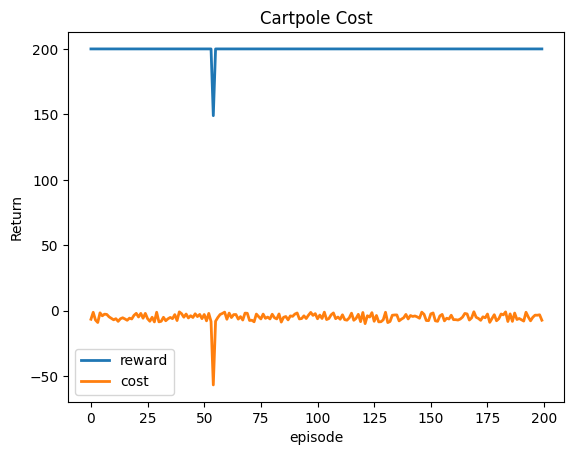

In [25]:
HORIZON = 200
GAMMA = 1
MU_P = 0.4
STD_DEV = 1

NUM_EPISODES = 200

env =  ContCartPoleFriction(horizon=HORIZON, gamma=GAMMA, mu_p = MU_P, render_mode="rgb_array")
s_dim = env.state_dim
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, 50, bias=False),
            nn.Tanh(),
            nn.Linear(50, 25, bias=False),
            nn.Tanh(),
            nn.Linear(25, a_dim, bias=False),
            nn.Tanh()
        )
model_desc = dict(
            layers_shape=[(s_dim, 50), (50, 25), (25, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters = np.load(r"C:\Users\Sara\Desktop\learnRL\results_bpo\test-friction-0.1_05_28-17_59_PG_150_cartpole_friction_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00\trial_0\policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )


all_episode_rewards = []
all_episode_costs = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    episode_costs = []
    done = False
    env.reset()
    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        if rew == 0 :
            cost = -1
        else:
            cost = - abs (math.sin(obs[2]))
        episode_rewards.append(rew * GAMMA ** t)
        episode_costs.append(cost * GAMMA ** t)
        if done:
            episode_costs.extend([-1] * (HORIZON - t - 1))
            break
    all_episode_rewards.append(sum(episode_rewards))
    all_episode_costs.append(sum(episode_costs))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)


plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Cartpole Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()

mean_episode_cost = np.mean(all_episode_costs)
std_episode_cost = np.std(all_episode_costs)
print("Mean cost:", mean_episode_cost,
        "Std cost:", std_episode_cost)


plt.plot(all_episode_costs, linewidth=2, label="cost")
plt.title("Cartpole Cost")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
plt.legend()
plt.show
plt.savefig(r"C:\Users\sara\Desktop\presentation\plots\friction_01-04")

frames = []
env.reset()
for t in range(HORIZON): # iterate over the steps until termination
    obs = env.state
    action = pol.draw_action(obs)
    obs, rew, done, _ = env.step(action)
    frames.append( env.render())
    if done:
        break

imageio.mimsave(r"C:\Users\sara\Desktop\presentation\gifs\friction_0.1-0.4.gif", frames, duration=33)

### Average reward with optimal policy for friction = 0.1, when friction is 0.5 on cartpole

100%|██████████| 200/200 [00:03<00:00, 62.47it/s]


Mean reward: 196.99 Std reward: 11.319006140116722
Mean cost: -8.484224815267835 Std cost: 11.800088551313888


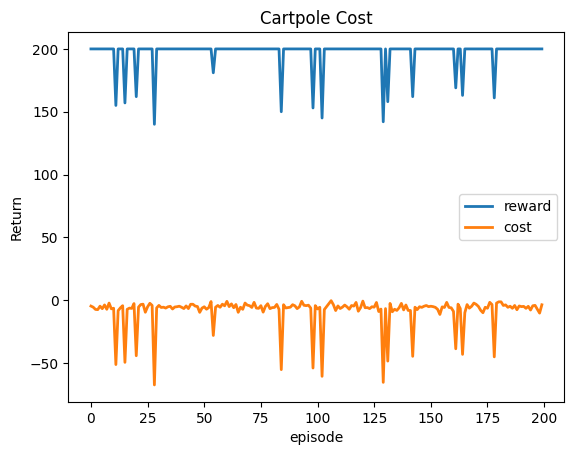

In [39]:
HORIZON = 200
GAMMA = 1
MU_P = 0.5
STD_DEV = 1

NUM_EPISODES = 200

env =  ContCartPoleFriction(horizon=HORIZON, gamma=GAMMA, mu_p = MU_P, render_mode="rgb_array")
s_dim = env.state_dim
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, 50, bias=False),
            nn.Tanh(),
            nn.Linear(50, 25, bias=False),
            nn.Tanh(),
            nn.Linear(25, a_dim, bias=False),
            nn.Tanh()
        )
model_desc = dict(
            layers_shape=[(s_dim, 50), (50, 25), (25, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters = np.load(r"C:\Users\Sara\Desktop\learnRL\results_bpo\test-friction-0.1_05_28-17_59_PG_150_cartpole_friction_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00\trial_0\policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )


all_episode_rewards = []
all_episode_costs = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    episode_costs = []
    done = False
    env.reset()
    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        if rew == 0 :
            cost = -1
        else:
            cost = - abs (math.sin(obs[2]))
        episode_rewards.append(rew * GAMMA ** t)
        episode_costs.append(cost * GAMMA ** t)
        if done:
            episode_costs.extend([-1] * (HORIZON - t - 1))
            break
    all_episode_rewards.append(sum(episode_rewards))
    all_episode_costs.append(sum(episode_costs))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)


plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Cartpole Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()

mean_episode_cost = np.mean(all_episode_costs)
std_episode_cost = np.std(all_episode_costs)
print("Mean cost:", mean_episode_cost,
        "Std cost:", std_episode_cost)


plt.plot(all_episode_costs, linewidth=2, label="cost")
plt.title("Cartpole Cost")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
plt.legend()
plt.show
plt.savefig(r"C:\Users\sara\Desktop\presentation\plots\friction_01-05")

frames = []
env.reset()
for t in range(HORIZON): # iterate over the steps until termination
    obs = env.state
    action = pol.draw_action(obs)
    obs, rew, done, _ = env.step(action)
    frames.append( env.render())
    if done:
        break

imageio.mimsave(r"C:\Users\sara\Desktop\presentation\gifs\friction_0.1-0.5.gif", frames, duration=33)

### Average reward with optimal policy for friction = 0.2, when friction is 0.2 on cartpole

100%|██████████| 200/200 [00:04<00:00, 46.72it/s]


Mean reward: 200.0 Std reward: 0.0
Mean cost: -3.263324972741208 Std cost: 1.6428688024006377


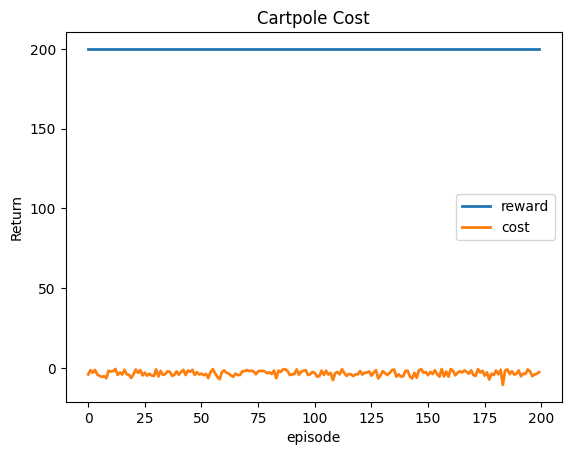

In [4]:
HORIZON = 200
GAMMA = 1
MU_P = 0.2
STD_DEV = 1

NUM_EPISODES = 200

env =  ContCartPoleFriction(horizon=HORIZON, gamma=GAMMA, mu_p = MU_P, render_mode = "rgb_array")
s_dim = env.state_dim
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, 50, bias=False),
            nn.Tanh(),
            nn.Linear(50, 25, bias=False),
            nn.Tanh(),
            nn.Linear(25, a_dim, bias=False),
            nn.Tanh()
        )
model_desc = dict(
            layers_shape=[(s_dim, 50), (50, 25), (25, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters = np.load(r"C:\Users\Sara\Desktop\learnRL\results_bpo\test-friction-0.2_05_28-19_07_PG_150_cartpole_friction_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00\trial_0\policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )


all_episode_rewards = []
all_episode_costs = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    episode_costs = []
    done = False
    env.reset()
    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        if rew == 0 :
            cost = -1
        else:
            cost = - abs (math.sin(obs[2]))
        episode_rewards.append(rew * GAMMA ** t)
        episode_costs.append(cost * GAMMA ** t)
        if done:
            episode_costs.extend([-1] * (HORIZON - t - 1))
            break
    all_episode_rewards.append(sum(episode_rewards))
    all_episode_costs.append(sum(episode_costs))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)


plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Cartpole Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
plt.savefig(r"C:\Users\sara\Desktop\presentation\plots\friction_02-02")

mean_episode_cost = np.mean(all_episode_costs)
std_episode_cost = np.std(all_episode_costs)
print("Mean cost:", mean_episode_cost,
        "Std cost:", std_episode_cost)


plt.plot(all_episode_costs, linewidth=2, label="cost")
plt.title("Cartpole Cost")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
plt.legend()
plt.show
plt.savefig(r"C:\Users\sara\Desktop\presentation\plots\friction_02-02")

frames = []
env.reset()
for t in range(HORIZON): # iterate over the steps until termination
    obs = env.state
    action = pol.draw_action(obs)
    obs, rew, done, _ = env.step(action)
    frames.append( env.render())
    if done:
        break

imageio.mimsave(r"C:\Users\sara\Desktop\presentation\gifs\friction_0.2-0.2.gif", frames, duration=33)

### Average reward with optimal policy for friction = 0.2, when friction is 0.3 on cartpole

100%|██████████| 200/200 [00:03<00:00, 53.07it/s]


Mean reward: 200.0 Std reward: 0.0
Mean cost: -3.6404711736309796 Std cost: 1.940726841138394


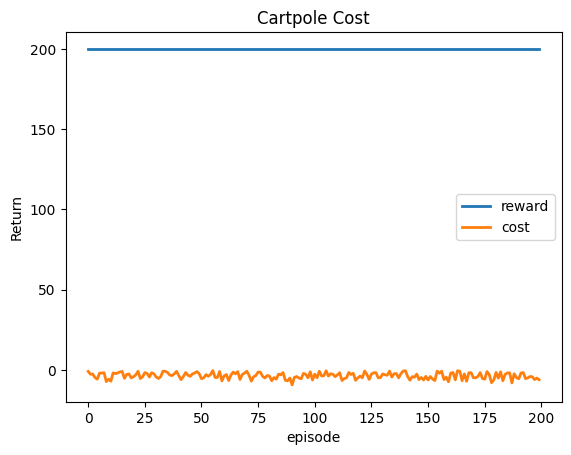

In [41]:
HORIZON = 200
GAMMA = 1
MU_P = 0.3
STD_DEV = 1

NUM_EPISODES = 200

env =  ContCartPoleFriction(horizon=HORIZON, gamma=GAMMA, mu_p = MU_P, render_mode="rgb_array")
s_dim = env.state_dim
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, 50, bias=False),
            nn.Tanh(),
            nn.Linear(50, 25, bias=False),
            nn.Tanh(),
            nn.Linear(25, a_dim, bias=False),
            nn.Tanh()
        )
model_desc = dict(
            layers_shape=[(s_dim, 50), (50, 25), (25, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters = np.load(r"C:\Users\Sara\Desktop\learnRL\results_bpo\test-friction-0.2_05_28-19_07_PG_150_cartpole_friction_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00\trial_0\policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )


all_episode_rewards = []
all_episode_costs = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    episode_costs = []
    done = False
    env.reset()
    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        if rew == 0 :
            cost = -1
        else:
            cost = - abs (math.sin(obs[2]))
        episode_rewards.append(rew * GAMMA ** t)
        episode_costs.append(cost * GAMMA ** t)
        if done:
            episode_costs.extend([-1] * (HORIZON - t - 1))
            break
    all_episode_rewards.append(sum(episode_rewards))
    all_episode_costs.append(sum(episode_costs))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)


plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Cartpole Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()

mean_episode_cost = np.mean(all_episode_costs)
std_episode_cost = np.std(all_episode_costs)
print("Mean cost:", mean_episode_cost,
        "Std cost:", std_episode_cost)


plt.plot(all_episode_costs, linewidth=2, label="cost")
plt.title("Cartpole Cost")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
plt.legend()
plt.show
plt.savefig(r"C:\Users\sara\Desktop\presentation\plots\friction_02-03")

frames = []
env.reset()
for t in range(HORIZON): # iterate over the steps until termination
    obs = env.state
    action = pol.draw_action(obs)
    obs, rew, done, _ = env.step(action)
    frames.append( env.render())
    if done:
        break

imageio.mimsave(r"C:\Users\sara\Desktop\presentation\gifs\friction_0.2-0.3.gif", frames, duration=33)

### Average reward with optimal policy for friction = 0.2, when friction is 0.4 on cartpole

100%|██████████| 200/200 [00:03<00:00, 60.20it/s]


Mean reward: 199.37 Std reward: 5.109119297882953
Mean cost: -5.424629321292062 Std cost: 6.021836325451108


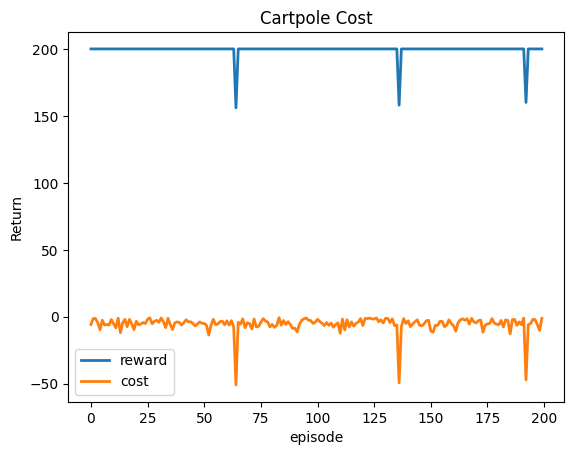

In [45]:
HORIZON = 200
GAMMA = 1
MU_P = 0.4
STD_DEV = 1

NUM_EPISODES = 200

env =  ContCartPoleFriction(horizon=HORIZON, gamma=GAMMA, mu_p = MU_P, render_mode="rgb_array")
s_dim = env.state_dim
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, 50, bias=False),
            nn.Tanh(),
            nn.Linear(50, 25, bias=False),
            nn.Tanh(),
            nn.Linear(25, a_dim, bias=False),
            nn.Tanh()
        )
model_desc = dict(
            layers_shape=[(s_dim, 50), (50, 25), (25, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters = np.load(r"C:\Users\Sara\Desktop\learnRL\results_bpo\test-friction-0.2_05_28-19_07_PG_150_cartpole_friction_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00\trial_0\policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )


all_episode_rewards = []
all_episode_costs = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    episode_costs = []
    done = False
    env.reset()
    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        if rew == 0 :
            cost = -1
        else:
            cost = - abs (math.sin(obs[2]))
        episode_rewards.append(rew * GAMMA ** t)
        episode_costs.append(cost * GAMMA ** t)
        if done:
            episode_costs.extend([-1] * (HORIZON - t - 1))
            break
    all_episode_rewards.append(sum(episode_rewards))
    all_episode_costs.append(sum(episode_costs))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)


plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Cartpole Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()

mean_episode_cost = np.mean(all_episode_costs)
std_episode_cost = np.std(all_episode_costs)
print("Mean cost:", mean_episode_cost,
        "Std cost:", std_episode_cost)


plt.plot(all_episode_costs, linewidth=2, label="cost")
plt.title("Cartpole Cost")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
plt.legend()
plt.show
plt.savefig(r"C:\Users\sara\Desktop\presentation\plots\friction_02-04")

frames = []
env.reset()
for t in range(HORIZON): # iterate over the steps until termination
    obs = env.state
    action = pol.draw_action(obs)
    obs, rew, done, _ = env.step(action)
    frames.append( env.render())
    if done:
        break

imageio.mimsave(r"C:\Users\sara\Desktop\presentation\gifs\friction_0.2-0.4.gif", frames, duration=33)

### Average reward with optimal policy for friction = 0.2, when friction is 0.5 on cartpole

  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [00:03<00:00, 61.83it/s]


Mean reward: 195.655 Std reward: 13.92429441659433
Mean cost: -9.404451327728866 Std cost: 14.670558157568523


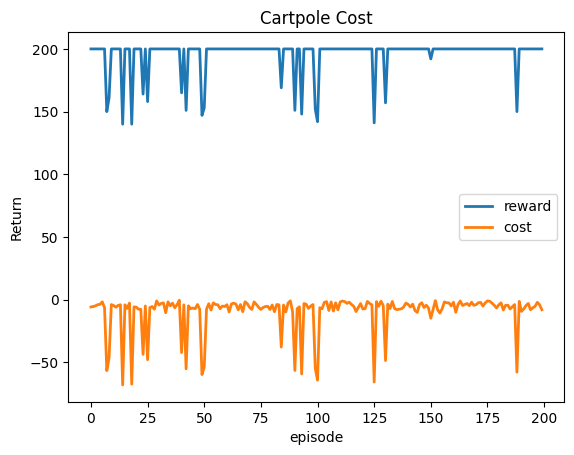

In [59]:
HORIZON = 200
GAMMA = 1
MU_P = 0.5
STD_DEV = 1

NUM_EPISODES = 200

env =  ContCartPoleFriction(horizon=HORIZON, gamma=GAMMA, mu_p = MU_P, render_mode="rgb_array")
s_dim = env.state_dim
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, 50, bias=False),
            nn.Tanh(),
            nn.Linear(50, 25, bias=False),
            nn.Tanh(),
            nn.Linear(25, a_dim, bias=False),
            nn.Tanh()
        )
model_desc = dict(
            layers_shape=[(s_dim, 50), (50, 25), (25, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters = np.load(r"C:\Users\Sara\Desktop\learnRL\results_bpo\test-friction-0.2_05_28-19_07_PG_150_cartpole_friction_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00\trial_0\policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )


all_episode_rewards = []
all_episode_costs = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    episode_costs = []
    done = False
    env.reset()
    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        if rew == 0 :
            cost = -1
        else:
            cost = - abs (math.sin(obs[2]))
        episode_rewards.append(rew * GAMMA ** t)
        episode_costs.append(cost * GAMMA ** t)
        if done:
            episode_costs.extend([-1] * (HORIZON - t - 1))
            break
    all_episode_rewards.append(sum(episode_rewards))
    all_episode_costs.append(sum(episode_costs))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)


plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Cartpole Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()

mean_episode_cost = np.mean(all_episode_costs)
std_episode_cost = np.std(all_episode_costs)
print("Mean cost:", mean_episode_cost,
        "Std cost:", std_episode_cost)


plt.plot(all_episode_costs, linewidth=2, label="cost")
plt.title("Cartpole Cost")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
plt.legend()
plt.show
plt.savefig(r"C:\Users\sara\Desktop\presentation\plots\friction_02-05")

frames = []
env.reset()
for t in range(HORIZON): # iterate over the steps until termination
    obs = env.state
    action = pol.draw_action(obs)
    obs, rew, done, _ = env.step(action)
    frames.append( env.render())
    if done:
        break

imageio.mimsave(r"C:\Users\sara\Desktop\presentation\gifs\friction_0.2-0.5.gif", frames, duration=33)

### Average reward with optimal policy for friction = 0.3, when friction is 0.3 on cartpole

100%|██████████| 200/200 [00:05<00:00, 34.84it/s]


Mean reward: 200.0 Std reward: 0.0
Mean cost: -10.097530502080929 Std cost: 5.417984131523312


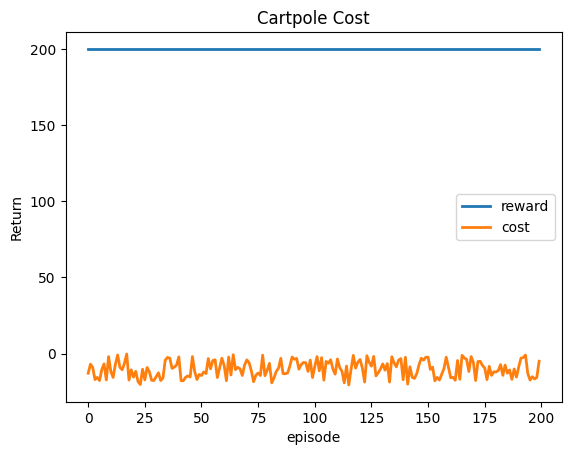

In [90]:
HORIZON = 200
GAMMA = 1
MU_P = 0.3
STD_DEV = 1

NUM_EPISODES = 200

env =  ContCartPoleFriction(horizon=HORIZON, gamma=GAMMA, mu_p = MU_P, render_mode="rgb_array")
s_dim = env.state_dim
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, 50, bias=False),
            nn.Tanh(),
            nn.Linear(50, 25, bias=False),
            nn.Tanh(),
            nn.Linear(25, a_dim, bias=False),
            
        )
model_desc = dict(
            layers_shape=[(s_dim, 50), (50, 25), (25, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters = np.load(r"C:\Users\Sara\Desktop\learnRL\results_bpo\test-friction-0.3_05_31-22_53_PG_100_cartpole_friction_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00\trial_0\policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )


all_episode_rewards = []
all_episode_costs = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    episode_costs = []
    done = False
    env.reset()
    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        action = pol.draw_action(obs)
        action = np.clip(action, env.action_space.low, env.action_space.high)
        obs, rew, done, _ = env.step(action)
        if rew == 0 :
            cost = -1
        else:
            cost = - abs (math.sin(obs[2]))
        episode_rewards.append(rew * GAMMA ** t)
        episode_costs.append(cost * GAMMA ** t)
        if done:
            episode_costs.extend([-1] * (HORIZON - t - 1))
            break
    all_episode_rewards.append(sum(episode_rewards))
    all_episode_costs.append(sum(episode_costs))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)


plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Cartpole Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()

mean_episode_cost = np.mean(all_episode_costs)
std_episode_cost = np.std(all_episode_costs)
print("Mean cost:", mean_episode_cost,
        "Std cost:", std_episode_cost)


plt.plot(all_episode_costs, linewidth=2, label="cost")
plt.title("Cartpole Cost")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
plt.legend()
plt.show
plt.savefig(r"C:\Users\sara\Desktop\presentation\plots\friction_03-03")

frames = []
env.reset()
for t in range(HORIZON): # iterate over the steps until termination
    obs = env.state
    action = pol.draw_action(obs)
    obs, rew, done, _ = env.step(action)
    frames.append( env.render())
    if done:
        break

imageio.mimsave(r"C:\Users\sara\Desktop\presentation\gifs\friction_0.3-0.3.gif", frames, duration=33)


### Average reward with optimal policy for friction = 0.3, when friction is 0.4 on cartpole

  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [00:03<00:00, 60.57it/s]


Mean reward: 199.805 Std reward: 2.7508135160348477
Mean cost: -4.946944514704889 Std cost: 3.493907421391454


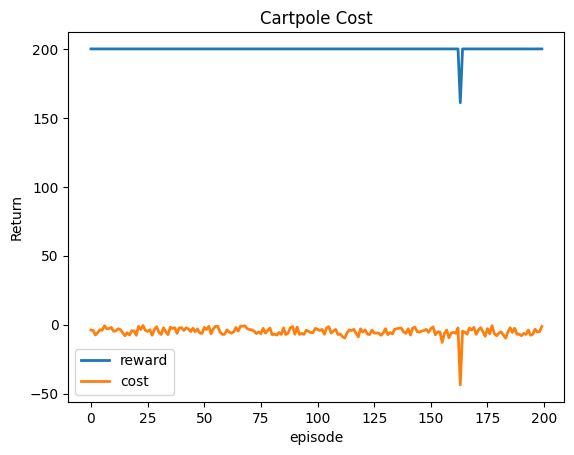

In [62]:
HORIZON = 200
GAMMA = 1
MU_P = 0.4
STD_DEV = 1

NUM_EPISODES = 200

env =  ContCartPoleFriction(horizon=HORIZON, gamma=GAMMA, mu_p = MU_P, render_mode="rgb_array")
s_dim = env.state_dim
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, 50, bias=False),
            nn.Tanh(),
            nn.Linear(50, 25, bias=False),
            nn.Tanh(),
            nn.Linear(25, a_dim, bias=False),
            nn.Tanh()
        )
model_desc = dict(
            layers_shape=[(s_dim, 50), (50, 25), (25, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters = np.load(r"C:\Users\Sara\Desktop\learnRL\results_bpo\test-friction-0.3_05_29-00_37_PG_150_cartpole_friction_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00\trial_0\policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )


all_episode_rewards = []
all_episode_costs = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    episode_costs = []
    done = False
    env.reset()
    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        if rew == 0 :
            cost = -1
        else:
            cost = - abs (math.sin(obs[2]))
        episode_rewards.append(rew * GAMMA ** t)
        episode_costs.append(cost * GAMMA ** t)
        if done:
            episode_costs.extend([-1] * (HORIZON - t - 1))
            break
    all_episode_rewards.append(sum(episode_rewards))
    all_episode_costs.append(sum(episode_costs))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)


plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Cartpole Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()

mean_episode_cost = np.mean(all_episode_costs)
std_episode_cost = np.std(all_episode_costs)
print("Mean cost:", mean_episode_cost,
        "Std cost:", std_episode_cost)


plt.plot(all_episode_costs, linewidth=2, label="cost")
plt.title("Cartpole Cost")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
plt.legend()
plt.show
plt.savefig(r"C:\Users\sara\Desktop\presentation\plots\friction_03-04")

frames = []
env.reset()
for t in range(HORIZON): # iterate over the steps until termination
    obs = env.state
    action = pol.draw_action(obs)
    obs, rew, done, _ = env.step(action)
    frames.append( env.render())
    if done:
        break

imageio.mimsave(r"C:\Users\sara\Desktop\presentation\gifs\friction_0.3-0.4.gif", frames, duration=33)

### Average reward with optimal policy for friction = 0.3, when friction is 0.5 on cartpole

100%|██████████| 200/200 [00:03<00:00, 62.04it/s]


Mean reward: 196.015 Std reward: 13.494990737306935
Mean cost: -8.811306685173282 Std cost: 13.996504723377349


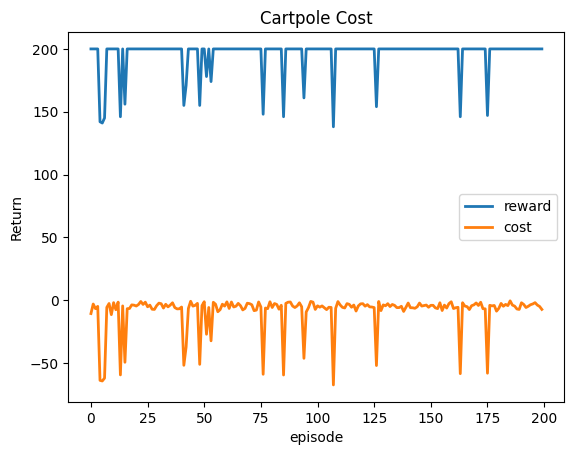

In [66]:
HORIZON = 200
GAMMA = 1
MU_P = 0.5
STD_DEV = 1

NUM_EPISODES = 200

env =  ContCartPoleFriction(horizon=HORIZON, gamma=GAMMA, mu_p = MU_P, render_mode="rgb_array")
s_dim = env.state_dim
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, 50, bias=False),
            nn.Tanh(),
            nn.Linear(50, 25, bias=False),
            nn.Tanh(),
            nn.Linear(25, a_dim, bias=False),
            nn.Tanh()
        )
model_desc = dict(
            layers_shape=[(s_dim, 50), (50, 25), (25, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters = np.load(r"C:\Users\Sara\Desktop\learnRL\results_bpo\test-friction-0.3_05_29-00_37_PG_150_cartpole_friction_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00\trial_0\policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )


all_episode_rewards = []
all_episode_costs = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    episode_costs = []
    done = False
    env.reset()
    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        if rew == 0 :
            cost = -1
        else:
            cost = - abs (math.sin(obs[2]))
        episode_rewards.append(rew * GAMMA ** t)
        episode_costs.append(cost * GAMMA ** t)
        if done:
            episode_costs.extend([-1] * (HORIZON - t - 1))
            break
    all_episode_rewards.append(sum(episode_rewards))
    all_episode_costs.append(sum(episode_costs))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)


plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Cartpole Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()

mean_episode_cost = np.mean(all_episode_costs)
std_episode_cost = np.std(all_episode_costs)
print("Mean cost:", mean_episode_cost,
        "Std cost:", std_episode_cost)


plt.plot(all_episode_costs, linewidth=2, label="cost")
plt.title("Cartpole Cost")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
plt.legend()
plt.show
plt.savefig(r"C:\Users\sara\Desktop\presentation\plots\friction_03-05")

frames = []
env.reset()
for t in range(HORIZON): # iterate over the steps until termination
    obs = env.state
    action = pol.draw_action(obs)
    obs, rew, done, _ = env.step(action)
    frames.append( env.render())
    if done:
        break

imageio.mimsave(r"C:\Users\sara\Desktop\presentation\gifs\friction_0.3-0.5.gif", frames, duration=33)

### Average reward with optimal policy for friction = 0.4, when friction is 0.4 on cartpole

100%|██████████| 200/200 [00:03<00:00, 65.43it/s]


Mean reward: 200.0 Std reward: 0.0
Mean cost: -5.163165267074821 Std cost: 2.5818406286537585


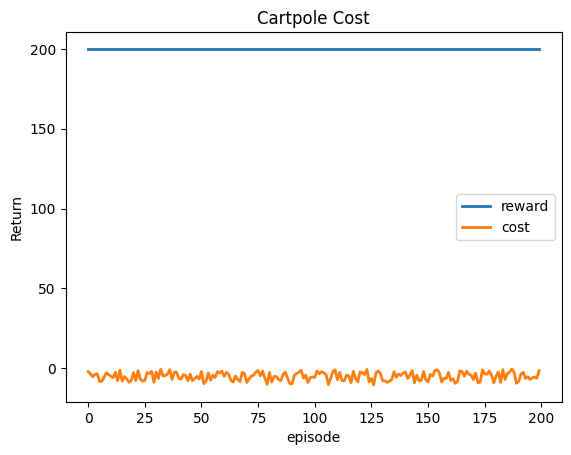

In [89]:
HORIZON = 200
GAMMA = 1
MU_P = 0.4
STD_DEV = 1

NUM_EPISODES = 200

env =  ContCartPoleFriction(horizon=HORIZON, gamma=GAMMA, mu_p = MU_P, render_mode="rgb_array")
s_dim = env.state_dim
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, 50, bias=False),
            nn.Tanh(),
            nn.Linear(50, 25, bias=False),
            nn.Tanh(),
            nn.Linear(25, a_dim, bias=False),
            nn.Tanh()
        )
model_desc = dict(
            layers_shape=[(s_dim, 50), (50, 25), (25, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters = np.load(r"C:\Users\Sara\Desktop\learnRL\results_bpo\test-friction-0.4_05_31-20_03_PG_300_cartpole_friction_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00\trial_0\policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )


all_episode_rewards = []
all_episode_costs = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    episode_costs = []
    done = False
    env.reset()
    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        if rew == 0 :
            cost = -1
        else:
            cost = - abs (math.sin(obs[2]))
        episode_rewards.append(rew * GAMMA ** t)
        episode_costs.append(cost * GAMMA ** t)
        if done:
            episode_costs.extend([-1] * (HORIZON - t - 1))
            break
    all_episode_rewards.append(sum(episode_rewards))
    all_episode_costs.append(sum(episode_costs))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)


plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Cartpole Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()

mean_episode_cost = np.mean(all_episode_costs)
std_episode_cost = np.std(all_episode_costs)
print("Mean cost:", mean_episode_cost,
        "Std cost:", std_episode_cost)


plt.plot(all_episode_costs, linewidth=2, label="cost")
plt.title("Cartpole Cost")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
plt.legend()
plt.show
plt.savefig(r"C:\Users\sara\Desktop\presentation\plots\friction_04-04")

frames = []
env.reset()
for t in range(HORIZON): # iterate over the steps until termination
    obs = env.state
    action = pol.draw_action(obs)
    obs, rew, done, _ = env.step(action)
    frames.append( env.render())
    if done:
        break

imageio.mimsave(r"C:\Users\sara\Desktop\presentation\gifs\friction_0.4-0.4.gif", frames, duration=33)

### Average reward with optimal policy for friction = 0.4, when friction is 0.5 on cartpole

100%|██████████| 200/200 [00:03<00:00, 64.14it/s]


Mean reward: 199.15 Std reward: 5.248571234155063
Mean cost: -5.311846018452213 Std cost: 5.657971747991746


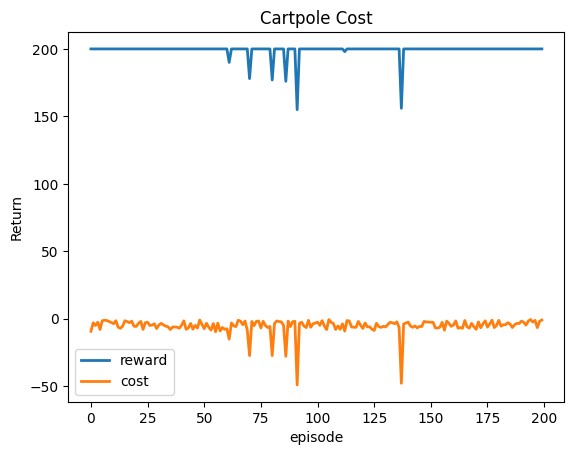

In [70]:
HORIZON = 200
GAMMA = 1
MU_P = 0.5
STD_DEV = 1

NUM_EPISODES = 200

env =  ContCartPoleFriction(horizon=HORIZON, gamma=GAMMA, mu_p = MU_P, render_mode="rgb_array")
s_dim = env.state_dim
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, 50, bias=False),
            nn.Tanh(),
            nn.Linear(50, 25, bias=False),
            nn.Tanh(),
            nn.Linear(25, a_dim, bias=False),
            nn.Tanh()
        )
model_desc = dict(
            layers_shape=[(s_dim, 50), (50, 25), (25, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters = np.load(r"C:\Users\Sara\Desktop\learnRL\results_bpo\test-friction-0.4_05_29-01_33_PG_150_cartpole_friction_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00\trial_0\policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )


all_episode_rewards = []
all_episode_costs = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    episode_costs = []
    done = False
    env.reset()
    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        if rew == 0 :
            cost = -1
        else:
            cost = - abs (math.sin(obs[2]))
        episode_rewards.append(rew * GAMMA ** t)
        episode_costs.append(cost * GAMMA ** t)
        if done:
            episode_costs.extend([-1] * (HORIZON - t - 1))
            break
    all_episode_rewards.append(sum(episode_rewards))
    all_episode_costs.append(sum(episode_costs))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)


plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Cartpole Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()

mean_episode_cost = np.mean(all_episode_costs)
std_episode_cost = np.std(all_episode_costs)
print("Mean cost:", mean_episode_cost,
        "Std cost:", std_episode_cost)


plt.plot(all_episode_costs, linewidth=2, label="cost")
plt.title("Cartpole Cost")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
plt.legend()
plt.show
plt.savefig(r"C:\Users\sara\Desktop\presentation\plots\friction_04-05")

frames = []
env.reset()
for t in range(HORIZON): # iterate over the steps until termination
    obs = env.state
    action = pol.draw_action(obs)
    obs, rew, done, _ = env.step(action)
    frames.append( env.render())
    if done:
        break

imageio.mimsave(r"C:\Users\sara\Desktop\presentation\gifs\friction_0.4-0.5.gif", frames, duration=33)

### Average reward with optimal policy for friction = 0.5, when friction is 0.5 on cartpole

100%|██████████| 200/200 [00:03<00:00, 58.76it/s]


Mean reward: 196.76 Std reward: 8.768260945022108
Mean cost: -9.491135837330678 Std cost: 9.391009835267843


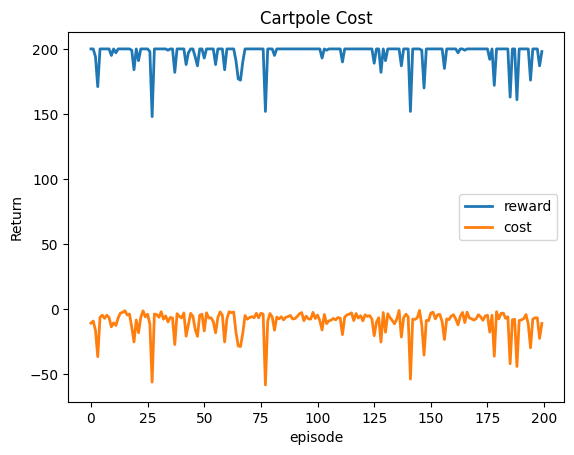

In [73]:
HORIZON = 200
GAMMA = 1
MU_P = 0.5
STD_DEV = 1

NUM_EPISODES = 200

env =  ContCartPoleFriction(horizon=HORIZON, gamma=GAMMA, mu_p = MU_P, render_mode="rgb_array")
s_dim = env.state_dim
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, 50, bias=False),
            nn.Tanh(),
            nn.Linear(50, 25, bias=False),
            nn.Tanh(),
            nn.Linear(25, a_dim, bias=False),
            nn.Tanh()
        )
model_desc = dict(
            layers_shape=[(s_dim, 50), (50, 25), (25, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters = np.load(r"C:\Users\Sara\Desktop\learnRL\results_bpo\test-friction-0.5_05_29-02_36_PG_150_cartpole_friction_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00\trial_0\policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )


all_episode_rewards = []
all_episode_costs = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    episode_costs = []
    done = False
    env.reset()
    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        if rew == 0 :
            cost = -1
        else:
            cost = - abs (math.sin(obs[2]))
        episode_rewards.append(rew * GAMMA ** t)
        episode_costs.append(cost * GAMMA ** t)
        if done:
            episode_costs.extend([-1] * (HORIZON - t - 1))
            break
    all_episode_rewards.append(sum(episode_rewards))
    all_episode_costs.append(sum(episode_costs))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)


plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Cartpole Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()

mean_episode_cost = np.mean(all_episode_costs)
std_episode_cost = np.std(all_episode_costs)
print("Mean cost:", mean_episode_cost,
        "Std cost:", std_episode_cost)


plt.plot(all_episode_costs, linewidth=2, label="cost")
plt.title("Cartpole Cost")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
plt.legend()
plt.show
plt.savefig(r"C:\Users\sara\Desktop\presentation\plots\friction_05-05")

frames = []
env.reset()
for t in range(HORIZON): # iterate over the steps until termination
    obs = env.state
    action = pol.draw_action(obs)
    obs, rew, done, _ = env.step(action)
    frames.append( env.render())
    if done:
        break

imageio.mimsave(r"C:\Users\sara\Desktop\presentation\gifs\friction_0.5-0.5.gif", frames, duration=33)

## Retraining Plots

<Figure size 640x480 with 0 Axes>

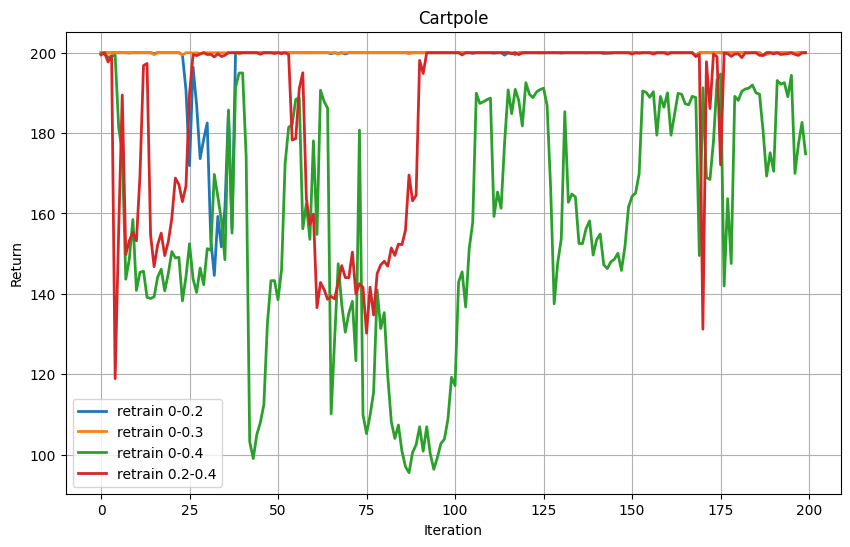

In [ ]:

paths = [
    r"C:\Users\Sara\Desktop\learnRL\results_retrain\friction-0-0.2_06_02-02_05_PG_200_cartpole_friction_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00",
    r"C:\Users\Sara\Desktop\learnRL\results_retrain\friction-0-0.3_06_02-03_14_PG_200_cartpole_friction_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00",
    r"C:\Users\Sara\Desktop\learnRL\results_retrain\friction-0-0.4_06_02-04_23_PG_200_cartpole_friction_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00",
    r"C:\Users\Sara\Desktop\learnRL\results_retrain\friction-02-04_06_02-12_49_PG_200_cartpole_friction_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00"
]
# Lista per memorizzare le performance per ogni set
all_performances = []
lab = ["retrain 0-0.2", "retrain 0-0.3", "retrain 0-0.4", "retrain 0.2-0.4"]
for path in paths:
    performances = load_trials(path, n_exp=10)
    if performances.size > 0:
        all_performances.append(performances)

# Plot dei grafici
plt.clf()
# plt.figure(figsize=(6.5, 4.5))
plt.figure(figsize=(10, 6))

for i, performances in enumerate(all_performances):
    if performances.size > 0:
         # Calcola la media e gli intervalli di confidenza
        mean_performance = np.mean(performances, axis=0)
        std_performance = np.std(performances, axis=0)

        # Plot della curva media
        plt.plot(mean_performance, linewidth=2, label=lab[i])

        # Plot dell'intervallo di confidenza
        lower = mean_performance-(std_performance)*1.96/np.sqrt(performances.shape[0])
        higher = mean_performance+(std_performance)*1.96/np.sqrt(performances.shape[0])

        plt.fill_between(
            range(len(mean_performance)),
            lower,
            higher,
            alpha=0.2
        )
        # print(np.mean(mean_performance))
        # print(np.mean(lower))
        # print(np.mean(higher))
# Etichette e titolo
plt.title("Cartpole")
plt.xlabel("Iteration")
plt.ylabel("Return")
plt.legend()
plt.grid()
plt.show()


Simulation of continuous chnage of friction 

  0%|          | 7/5000 [00:00<01:21, 61.52it/s]

current mu = 0


 20%|██        | 1010/5000 [00:17<01:03, 63.18it/s]

current mu = 0.09999999999999999


 40%|████      | 2008/5000 [00:33<00:50, 59.84it/s]

...

current mu = 0.3000000000000001


 80%|████████  | 4007/5000 [01:07<00:16, 60.11it/s]

current mu = 0.4000000000000002


100%|██████████| 5000/5000 [01:23<00:00, 59.57it/s]


Mean reward: 199.751 Std reward: 3.6191986682137247
Mean cost: -5.256301020057353 Std cost: 4.837049397512157


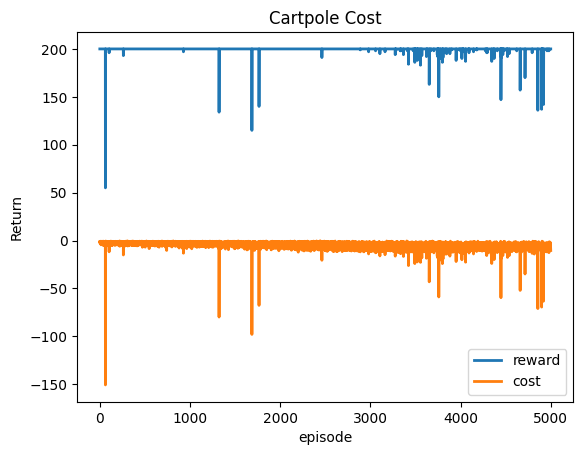

In [16]:
HORIZON = 200
GAMMA = 1
MU_P = 0
STD_DEV = 1
NUM_EPISODES = 5000

env =  ContCartPoleFriction(horizon=HORIZON, gamma=GAMMA, mu_p = MU_P, render_mode="rgb_array")
s_dim = env.state_dim
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, 50, bias=False),
            nn.Tanh(),
            nn.Linear(50, 25, bias=False),
            nn.Tanh(),
            nn.Linear(25, a_dim, bias=False),
            nn.Tanh()
        )
model_desc = dict(
            layers_shape=[(s_dim, 50), (50, 25), (25, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters = np.load(r"C:\Users\Sara\Desktop\learnRL\results_bpo\test_05_28-12_53_PG_300_cartpole_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00\trial_0\policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )


all_episode_rewards = []
all_episode_costs = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    episode_costs = []
    done = False
    if i % 1000 == 0 :
        print(f"current mu = {MU_P}")
    if i % 100 == 0:
        MU_P += 0.01
        env =  ContCartPoleFriction(horizon=HORIZON, gamma=GAMMA, mu_p = MU_P, render_mode="rgb_array")        
    env.reset()
    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        if rew == 0 :
            cost = -1
        else:
            cost = - abs (math.sin(obs[2]))
        episode_rewards.append(rew * GAMMA ** t)
        episode_costs.append(cost * GAMMA ** t)
        if done:
            episode_costs.extend([-1] * (HORIZON - t - 1))
            break
    all_episode_rewards.append(sum(episode_rewards))
    all_episode_costs.append(sum(episode_costs))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)


plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Cartpole Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()

mean_episode_cost = np.mean(all_episode_costs)
std_episode_cost = np.std(all_episode_costs)
print("Mean cost:", mean_episode_cost,
        "Std cost:", std_episode_cost)


plt.plot(all_episode_costs, linewidth=2, label="cost")
plt.title("Cartpole Cost")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
plt.legend()
plt.show
plt.savefig(r"C:\Users\sara\Desktop\presentation\plots_simulation\no_retrain")


Simulating retraing at 0.3

  0%|          | 7/5000 [00:00<01:21, 61.50it/s]

current mu = 0


 20%|██        | 1008/5000 [00:16<00:59, 66.91it/s]

current mu = 0.1


 40%|████      | 2013/5000 [00:33<00:49, 60.89it/s]

...

current mu = 0.3
 ------- Simulating retrain at mu = 0.3


 80%|████████  | 4007/5000 [01:09<00:16, 59.99it/s]

current mu = 0.4


100%|██████████| 5000/5000 [01:25<00:00, 58.77it/s]


Mean reward: 199.8042 Std reward: 3.614507208458713
Mean cost: -4.8926129691015 Std cost: 4.677419405161547


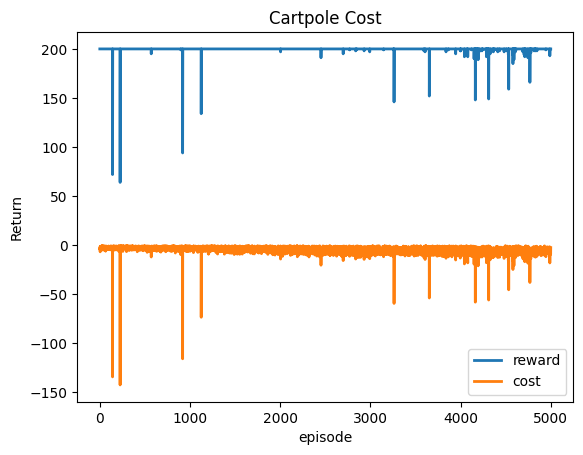

In [18]:
HORIZON = 200
GAMMA = 1
MU_P = 0
STD_DEV = 1
NUM_EPISODES = 5000

env =  ContCartPoleFriction(horizon=HORIZON, gamma=GAMMA, mu_p = MU_P, render_mode="rgb_array")
s_dim = env.state_dim
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, 50, bias=False),
            nn.Tanh(),
            nn.Linear(50, 25, bias=False),
            nn.Tanh(),
            nn.Linear(25, a_dim, bias=False),
            nn.Tanh()
        )
model_desc = dict(
            layers_shape=[(s_dim, 50), (50, 25), (25, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters = np.load(r"C:\Users\Sara\Desktop\learnRL\results_bpo\test_05_28-12_53_PG_300_cartpole_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00\trial_0\policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )


all_episode_rewards = []
all_episode_costs = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    episode_costs = []
    done = False
    if i % 1000 == 0 :
        print(f"current mu = {MU_P}")
    if i % 100 == 0:
        MU_P = round(MU_P + 0.01, 2)
        env =  ContCartPoleFriction(horizon=HORIZON, gamma=GAMMA, mu_p = MU_P, render_mode="rgb_array")        
    env.reset()
    if i == 3000 :
        print(" ------- Simulating retrain at mu = 0.3")
        pol = DeepGaussianPolicy(
            parameters = np.load(r"C:\Users\Sara\Desktop\learnRL\results_retrain\friction-0-0.3_06_02-03_14_PG_200_cartpole_friction_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00\trial_0\policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )

    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        if rew == 0 :
            cost = -1
        else:
            cost = - abs (math.sin(obs[2]))
        episode_rewards.append(rew * GAMMA ** t)
        episode_costs.append(cost * GAMMA ** t)
        if done:
            episode_costs.extend([-1] * (HORIZON - t - 1))
            break
    all_episode_rewards.append(sum(episode_rewards))
    all_episode_costs.append(sum(episode_costs))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)


plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Cartpole Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()

mean_episode_cost = np.mean(all_episode_costs)
std_episode_cost = np.std(all_episode_costs)
print("Mean cost:", mean_episode_cost,
        "Std cost:", std_episode_cost)


plt.plot(all_episode_costs, linewidth=2, label="cost")
plt.title("Cartpole Cost")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
plt.legend()
plt.show
plt.savefig(r"C:\Users\sara\Desktop\presentation\plots_simulation\retrain_at_03")


Simulating retrain at Mu = 0.2 and mu = 0.4

  0%|          | 0/5000 [00:00<?, ?it/s]

current mu = 0


 20%|██        | 1006/5000 [00:18<01:05, 60.94it/s]

current mu = 0.1


 40%|████      | 2011/5000 [00:36<00:48, 61.86it/s]

...

current mu = 0.3


 80%|████████  | 4011/5000 [01:11<00:16, 61.62it/s]

current mu = 0.4
 ------- Simulating retrain at mu = 0.4


100%|██████████| 5000/5000 [01:27<00:00, 57.11it/s]


Mean reward: 199.936 Std reward: 2.29126689846469
Mean cost: -3.949591243468746 Std cost: 3.251985892251302


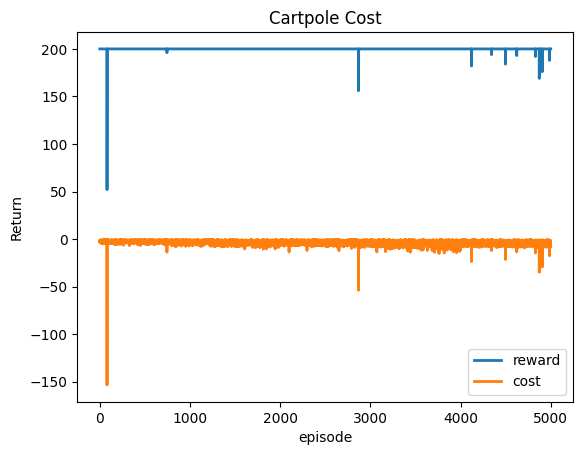

In [19]:
HORIZON = 200
GAMMA = 1
MU_P = 0
STD_DEV = 1
NUM_EPISODES = 5000

env =  ContCartPoleFriction(horizon=HORIZON, gamma=GAMMA, mu_p = MU_P, render_mode="rgb_array")
s_dim = env.state_dim
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, 50, bias=False),
            nn.Tanh(),
            nn.Linear(50, 25, bias=False),
            nn.Tanh(),
            nn.Linear(25, a_dim, bias=False),
            nn.Tanh()
        )
model_desc = dict(
            layers_shape=[(s_dim, 50), (50, 25), (25, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters = np.load(r"C:\Users\Sara\Desktop\learnRL\results_bpo\test_05_28-12_53_PG_300_cartpole_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00\trial_0\policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )


all_episode_rewards = []
all_episode_costs = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    episode_costs = []
    done = False
    if i % 1000 == 0 :
        print(f"current mu = {MU_P}")
    if i % 100 == 0:
        MU_P = round(MU_P + 0.01, 2)
        env =  ContCartPoleFriction(horizon=HORIZON, gamma=GAMMA, mu_p = MU_P, render_mode="rgb_array")        
    env.reset()
    if i == 2000 :
        print(" ------- Simulating retrain at mu = 0.2")
        pol = DeepGaussianPolicy(
            parameters = np.load(r"C:\Users\Sara\Desktop\learnRL\results_retrain\friction-0-0.2_06_02-02_05_PG_200_cartpole_friction_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00\trial_0\policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )
    if i == 4000 :
        print(" ------- Simulating retrain at mu = 0.4")
        pol = DeepGaussianPolicy(
            parameters = np.load(r"C:\Users\Sara\Desktop\learnRL\results_retrain\friction-02-04_06_02-12_49_PG_200_cartpole_friction_200_10_constant_001_100_noclip__deep_gaussian_1475_std_1_noise_00\trial_0\policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )

    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        if rew == 0 :
            cost = -1
        else:
            cost = - abs (math.sin(obs[2]))
        episode_rewards.append(rew * GAMMA ** t)
        episode_costs.append(cost * GAMMA ** t)
        if done:
            episode_costs.extend([-1] * (HORIZON - t - 1))
            break
    all_episode_rewards.append(sum(episode_rewards))
    all_episode_costs.append(sum(episode_costs))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)


plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Cartpole Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()

mean_episode_cost = np.mean(all_episode_costs)
std_episode_cost = np.std(all_episode_costs)
print("Mean cost:", mean_episode_cost,
        "Std cost:", std_episode_cost)


plt.plot(all_episode_costs, linewidth=2, label="cost")
plt.title("Cartpole Cost")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
plt.legend()
plt.show
plt.savefig(r"C:\Users\sara\Desktop\presentation\plots_simulation\retrain_at_02_04")
